In [1]:
# Import all necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.model_selection import train_test_split
from sklearn import svm, datasets
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model.logistic import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\deprecation.py:144: FutureWarning: The sklearn.linear_model.logistic module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.linear_model. Anything that cannot be imported from sklearn.linear_model is now part of the private API.
  warnings.warn(message, FutureWarning)


In [2]:
# generate 2 class dataset
x, y = make_classification(n_samples=10000, n_classes=2, weights=[0.9,0.5],
random_state=42)

# Split data into train and test subsets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8)

In [3]:
# Set parameters for grid-search.
param_grid = [{'weights': ['uniform', 'distance'], 'n_neighbors': [1, 2, 3, 4, 5, 10, 15, 20]}]
clf = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, verbose=3, n_jobs=-1)
clf.fit(x, y)
print('Número de Vizinhos mais proximos:', clf.best_params_.get('n_neighbors'))
print('Peso de cada Vizinho dado por: ', clf.best_params_.get('weights'))
print('Precisão do Classificador kNN', clf.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    5.9s


Número de Vizinhos mais proximos: 20
Peso de cada Vizinho dado por:  distance
Precisão do Classificador kNN 0.8852


[Parallel(n_jobs=-1)]: Done  80 out of  80 | elapsed:   25.0s finished


In [4]:
# Classificador kNN

# Create an instance of Neighbours Classifier and fit the data.
clf = KNeighborsClassifier(n_neighbors=20, weights='distance')
# Train the classifier.
clf.fit(x_train, y_train)
# Getting the probabilities for each class
y_prob1 = clf.predict_proba(x_test) 

In [5]:
# Classificador GaussianNB()

gnb = GaussianNB()
# Train the classifier.
gnb.fit(x_train, y_train)
# Getting the probabilities for each class
y_prob2 = gnb.predict_proba(x_test)

In [6]:
# Classificador LogisticRegression()

lg = LogisticRegression()
# Train the classifier.
lg.fit(x_train, y_train)
# Getting the probabilities for each class
y_prob3 = lg.predict_proba(x_test)

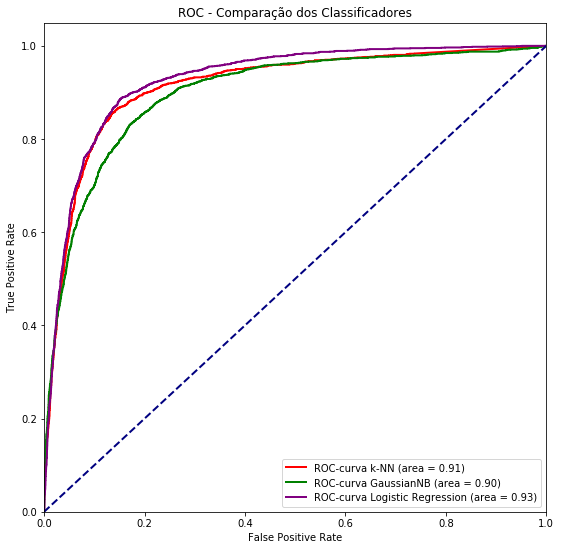

In [7]:
# Compute ROC curve and ROC area for each class.
plt.figure(figsize=(9, 9))

fpr1, tpr1, _ = roc_curve(y_test, y_prob1[:, 1])
fpr2, tpr2, _ = roc_curve(y_test, y_prob2[:, 1])
fpr3, tpr3, _ = roc_curve(y_test, y_prob3[:, 1])

roc_auc1 = auc(fpr1, tpr1)
roc_auc2 = auc(fpr2, tpr2)
roc_auc3 = auc(fpr3, tpr3)

# Plotting ROC curve.
lw = 2
plt.plot(fpr1, tpr1, color='red', lw=lw, label='ROC-curva k-NN (area = %0.2f)' % roc_auc1)
plt.plot(fpr2, tpr2, color='green', lw=lw, label='ROC-curva GaussianNB (area = %0.2f)' % roc_auc2)
plt.plot(fpr3, tpr3, color='purple', lw=lw, label='ROC-curva Logistic Regression (area = %0.2f)' % roc_auc3)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Comparação dos Classificadores')
plt.legend(loc="lower right")
plt.show()

**R: O classificador k-NN apresenta a melhor performance.**